# Random Forest

Notebook para preparar los datos, entrenar un
Random Forest sobre el dataset del equipo y guardar el modelo.


## 1. Montar Drive y clonar el repositorio

In [1]:
# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

# Clonar el repositorio sin descargar todo el contenido
!git clone --filter=blob:none --no-checkout https://github.com/efhes/IE-workspace.git

%cd IE-workspace

# Activar sparse checkout
!git sparse-checkout init --cone

# Seleccionar las carpetas necesarias
!git sparse-checkout set HAR_mediapipe common

# Descargar solo esas carpetas
!git checkout

Mounted at /content/drive
Cloning into 'IE-workspace'...
remote: Enumerating objects: 415, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 415 (delta 19), reused 17 (delta 7), pack-reused 383 (from 1)
Receiving objects: 100% (415/415), 67.76 KiB | 564.00 KiB/s, done.
Resolving deltas: 100% (162/162), done.
/content/IE-workspace
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 333 (delta 3), reused 2 (delta 1), pack-reused 320 (from 1)
Receiving objects: 100% (333/333), 82.05 MiB | 10.93 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (335/335), done.
Your branch is up to date with 'origin/master'.


## 2. Instalar librerías

In [2]:
!pip install -q mediapipe opencv-python tensorflow scikit-learn pandas keras matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 6.7 MB/s eta 0:00:00


## 3. Definir rutas e importar librerías del proyecto

In [3]:
import os, sys

# Rutas del proyecto clonado en Colab
sys.path.append('/content/IE-workspace/HAR_mediapipe/src/')
sys.path.append('/content/IE-workspace/common/')

import landmarksLib
import config
print("landmarksLib y config importados correctamente")


landmarksLib y config importados correctamente


In [4]:
root_path = r'HAR_mediapipe/' # r'/content/IE-workspace/HAR_mediapipe/'

# Folder where the input data is saved
data_path = root_path + r'data/'
new_dataset_path = data_path + r'new_dataset_final/' # Change 'new_dataset' as needed
new_dataset_annotations_path = new_dataset_path + r'annotations/'
new_dataset_landmarks_path = new_dataset_path + r'landmarks/'
dataset_path = {}
dataset_path['train'] = new_dataset_path + r'train/'
dataset_path['test'] = new_dataset_path + r'test/'

# Folder where the models are stored
models_path = root_path + r'models/'

# SUMMARY
print('data_path = ', data_path)
print('new_dataset_path = ', new_dataset_path)
print('new_dataset_annotations_path = ', new_dataset_annotations_path)
print('new_dataset_landmarks_path = ', new_dataset_landmarks_path)
print('dataset_path[train] = ', dataset_path['train'])
print('dataset_path[test] = ', dataset_path['test'])
print('models_path = ', models_path)

data_path =  HAR_mediapipe/data/
new_dataset_path =  HAR_mediapipe/data/new_dataset_final/
new_dataset_annotations_path =  HAR_mediapipe/data/new_dataset_final/annotations/
new_dataset_landmarks_path =  HAR_mediapipe/data/new_dataset_final/landmarks/
dataset_path[train] =  HAR_mediapipe/data/new_dataset_final/train/
dataset_path[test] =  HAR_mediapipe/data/new_dataset_final/test/
models_path =  HAR_mediapipe/models/


## 4. Cargar el dataset del equipo (`new_dataset_final`)

Copia el `.zip` desde tu Drive y lo descomprime con `zipfile` (más fiable que
`unzip` para los zips que genera Google Drive).

**Ajusta `zip_en_drive`** a la ruta real del zip en tu Drive
(usa el `find` de abajo si no la sabes).

In [9]:
# Localiza el zip en Drive
#!find /content/drive -name "new_dataset_final.zip" 2>/dev/null

import os, shutil, zipfile

zip_en_drive = "/content/drive/MyDrive/new_dataset_final.zip"
dest_dir     = "/content/IE-workspace/HAR_mediapipe/data/"
os.makedirs(dest_dir, exist_ok=True)

zip_local = os.path.join(dest_dir, "new_dataset_final.zip")
shutil.copy(zip_en_drive, zip_local)
print("Copiado:", os.path.getsize(zip_local)/1e6, "MB")

with zipfile.ZipFile(zip_local, 'r') as z:
    assert z.testzip() is None, "El zip está corrupto"
    z.extractall(dest_dir)
print("Descomprimido en", dest_dir)


Copiado: 67.285237 MB
Descomprimido en /content/IE-workspace/HAR_mediapipe/data/


In [10]:
# Comprobar la estructura del dataset
import os
for split in ['train', 'test']:
    print(f"=== {split.upper()} ===")
    base = f'/content/IE-workspace/HAR_mediapipe/data/new_dataset_final/{split}/'
    for gesto in sorted(os.listdir(base)):
        print(f"{gesto}: {len(os.listdir(base + gesto))}")


=== TRAIN ===
No_Ok: 133
OK: 132
Perfecto: 133
Puno_de_frente: 133
Spiderman: 133
Uno: 133
=== TEST ===
No_Ok: 57
OK: 57
Perfecto: 57
Puno_de_frente: 57
Spiderman: 57
Uno: 57


## 5. Extracción de landmarks (MediaPipe)

In [11]:
import os
from config import Config
from config import ConfigMediapipeDetector
from landmarksLib import GetLandmarksFromImages

detector_path = models_path + f'hand_landmarker.task' #'/content/IE-workspace/HAR_mediapipe/models/hand_landmarker.task'

if __name__ == '__main__':
  config = Config(save_images=True)

  # Create the detector
  detector = ConfigMediapipeDetector(detector_path)

  num_successful_detections = {}
  num_successful_detections['train'] = {}
  num_successful_detections['test'] = {}
  num_failed_detections = {}
  num_failed_detections['train'] = {}
  num_failed_detections['test'] = {}

  for mode in ['train', 'test']:
    print('\n[Processing input data...][%s]' % mode)
    for images_class in os.listdir(dataset_path[mode]):
      print('\n\t[New class][%s]' % images_class) # ok

      #images_symbol_path = os.path.join(original_data_path, symbol)
      class_folder_path = os.path.join(dataset_path[mode], images_class)
      print('\t[Folder][%s]' % class_folder_path) # ok

      IMAGE_FILES = os.listdir(class_folder_path)

      (df_successful_detections,
      num_successful_detections[mode][images_class],
      num_failed_detections[mode][images_class] ) = GetLandmarksFromImages(
          detector,
          IMAGE_FILES,
          dataset_path[mode], # Folder where the images are stored
          mode, # This is the subfolder where the images are stored (train/test)
          images_class, # This is the class of the images
          new_dataset_landmarks_path, # Folder where the landmarks will be saved
          new_dataset_annotations_path, # Folder where the annotations will be saved
          config)

  print('\n[SUMMARY OF SUCCESSFUL DETECTIONS]')
  num_total_ok = 0
  num_total_wrong = 0
  for mode in ['train', 'test']:
    for class_folder in os.listdir(dataset_path[mode]):
      num_total_ok = num_total_ok + num_successful_detections[mode][class_folder]
      num_total_wrong = num_total_wrong + num_failed_detections[mode][class_folder]
      print('\t[%s][%s][%d out of %d][%0.2f]' % (mode, class_folder,
        num_successful_detections[mode][class_folder],
        num_successful_detections[mode][class_folder]+num_failed_detections[mode][class_folder],
        100*num_successful_detections[mode][class_folder]/(num_successful_detections[mode][class_folder]+num_failed_detections[mode][class_folder])))

  print('[NUM TOTAL SUCCESSFUL = %d][%0.2f]' % (num_total_ok, 100*num_total_ok/(num_total_ok+num_total_wrong)))
  print('[NUM TOTAL FAILED = %d][%0.2f]' % (num_total_wrong, 100*num_total_wrong/(num_total_ok+num_total_wrong)))


[Processing input data...][train]

	[New class][Perfecto]
	[Folder][HAR_mediapipe/data/new_dataset_final/train/Perfecto]
	[HAR_mediapipe/data/new_dataset_final/landmarks//train/][Folder does not exist!!! We create it!]
	[HAR_mediapipe/data/new_dataset_final/annotations//train/][Folder does not exist!!! We create it!]
	[HAR_mediapipe/data/new_dataset_final/annotations//train/Perfecto/][Folder does not exist!!! We create it!]
	[New .csv file with landmarks][HAR_mediapipe/data/new_dataset_final/landmarks//train//train_Perfecto_poses_landmarks.csv]

[GetLandmarksFromImages]
	[files][['guille_Perfecto_00007.jpg', 'david_Perfecto_00001.jpg', 'david_Perfecto_00004.jpg', 'carlos_Perfecto_00015.jpg', 'Alfonso_Perfecto_00029.jpg', 'david_Perfecto_00009.jpg', 'david_Perfecto_00026.jpg', 'guille_Perfecto_00020.jpg', 'Alfonso_Perfecto_00022.jpg', 'Alfonso_Perfecto_00021.jpg', 'Alfonso_Perfecto_00016.jpg', 'Antonio_Perfecto_00006.jpg', 'david_Perfecto_00028.jpg', 'david_Perfecto_00008.jpg', 'david_

## 6. Generar CSV y ficheros .npy

In [12]:
from landmarksLib import extract_classes_list_from_folders, sorted_lists_match, load_individual_class_features_and_create_labeled_csv_dataset, create_numpy_with_feats_and_csv_with_just_labels

# Make the following True if you want your model to include a NO_GESTURE class
plus_NO_GESTURE = True

# Execute once
print("Loading data...")

classes_train = extract_classes_list_from_folders(dataset_path['train'], new_dataset_path)
classes_test = extract_classes_list_from_folders(dataset_path['test'], new_dataset_path)

print('\n[TRAIN]', classes_train)
print('[TEST]', classes_train)

if sorted_lists_match(classes_train, classes_test) == False:
  print('\n[ERROR!!!]\n[extract_classes_list_from_folders][sorted_lists_match][False]\n')
  exit()

load_individual_class_features_and_create_labeled_csv_dataset('train', new_dataset_path, new_dataset_landmarks_path)
load_individual_class_features_and_create_labeled_csv_dataset('test', new_dataset_path, new_dataset_landmarks_path)

create_numpy_with_feats_and_csv_with_just_labels('train', new_dataset_path)
create_numpy_with_feats_and_csv_with_just_labels('test', new_dataset_path)

Loading data...

[extract_classes_list_from_folders][NEW .txt file]
	[HAR_mediapipe/data/new_dataset_final//train_classes_list.txt]

[extract_classes_list_from_folders][NEW .txt file]
	[HAR_mediapipe/data/new_dataset_final//test_classes_list.txt]

[TRAIN] ['No_Ok', 'OK', 'Perfecto', 'Puno_de_frente', 'Spiderman', 'Uno']
[TEST] ['No_Ok', 'OK', 'Perfecto', 'Puno_de_frente', 'Spiderman', 'Uno']

[load_individual_class_features_and_create_labeled_csv_dataset][train]
	[LOAD .txt file with the list of classes][HAR_mediapipe/data/new_dataset_final//train_classes_list.txt]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset_final/landmarks/train/train_No_Ok_poses_landmarks.csv]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset_final/landmarks/train/train_OK_poses_landmarks.csv]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset_final/landmarks/train/train_Perfecto_poses_landmarks.csv]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset_final/l

## 7. Número de clases

In [13]:
import pandas as pd
import numpy as np

# Number of classes
data_path = new_dataset_path
classes_list = pd.read_csv(data_path + '/' + 'train_classes_list.txt', header=None)
num_classes = len(classes_list)

print(f'\n[NUM CLASSES = {num_classes} classes]')


[NUM CLASSES = 6 classes]


## 8. Añadir la clase NO_GESTURE

In [15]:
# Lee el CSV de train para inspeccionar el número de muestras por clase
df = pd.read_csv(new_dataset_path + '/train_dataset_with_labels.csv')

num_samples_per_class = df['label'].value_counts()
average_num_samples_per_class = int(np.mean(num_samples_per_class))
print('num_samples_per_class')
print(num_samples_per_class)
print('average_num_samples_per_class = ', average_num_samples_per_class)

num_samples_per_class
label
5.0    133
3.0    133
4.0    132
6.0    131
2.0    129
1.0    129
Name: count, dtype: int64
average_num_samples_per_class =  131


In [16]:
if plus_NO_GESTURE:
  no_gesture_class = num_classes + 1
  num_landmarks_coordinates = config.num_landmarks * 2

  for input_mode in ['train', 'test']:
    input_filename = new_dataset_path + '/' + input_mode + '_dataset_with_labels.csv'
    print('\n[LOAD .csv file][%s]' % input_filename)
    df = pd.read_csv(input_filename)

    # Add as many new examples as there are examples from other classes
    num_samples_per_class = df['label'].value_counts()
    average_num_samples_per_class = int(np.mean(num_samples_per_class))

    # Create the new row
    new_row = pd.DataFrame([[0]*num_landmarks_coordinates + [no_gesture_class] + ['NO_GESTURE'] + ['No gesture - No URL']], columns=df.columns)

    # These are for the NO GESTURE class; We add as many new rows as average_num_samples_per_class
    for i in range(average_num_samples_per_class):
        df = pd.concat([df,new_row], ignore_index=True)

    print('\t[%d NEW samples for NO GESTURE class]' % average_num_samples_per_class)

    # Save
    output_filename = new_dataset_path + '/' + input_mode + '_dataset_with_labels_plus_NO_GESTURE.csv'
    print('\n[NEW .csv file][%s]' % output_filename)
    df.to_csv(output_filename, index=False)

    # We can now reutilize 'create_numpy_with_feats_and_csv_with_just_labels'
    # to create coherent .npy and .csv files
    create_numpy_with_feats_and_csv_with_just_labels(input_mode, new_dataset_path, NO_GESTURE=True)



[LOAD .csv file][HAR_mediapipe/data/new_dataset_final//train_dataset_with_labels.csv]
	[131 NEW samples for NO GESTURE class]

[NEW .csv file][HAR_mediapipe/data/new_dataset_final//train_dataset_with_labels_plus_NO_GESTURE.csv]

[create_numpy_with_feats_and_csv_with_just_labels][train]
	[input_file][HAR_mediapipe/data/new_dataset_final//train_dataset_with_labels_plus_NO_GESTURE.csv]
	[NEW .csv][HAR_mediapipe/data/new_dataset_final//train_labels_plus_NO_GESTURE.csv]
	[NEW .npy][HAR_mediapipe/data/new_dataset_final//train_dataset_plus_NO_GESTURE.npy]

[LOAD .csv file][HAR_mediapipe/data/new_dataset_final//test_dataset_with_labels.csv]
	[56 NEW samples for NO GESTURE class]

[NEW .csv file][HAR_mediapipe/data/new_dataset_final//test_dataset_with_labels_plus_NO_GESTURE.csv]

[create_numpy_with_feats_and_csv_with_just_labels][test]
	[input_file][HAR_mediapipe/data/new_dataset_final//test_dataset_with_labels_plus_NO_GESTURE.csv]
	[NEW .csv][HAR_mediapipe/data/new_dataset_final//test_labels_

## 9. Preparación final de los datos

Normalización **L0** (respecto a la muñeca) para ser comparable con el resto de modelos.

In [17]:
import random
from landmarksLib import ArrangeInputDataForNetwork, normalize_from_0_landmark

print('\n[DATA PREPARATION]')

debug = False
norm_type = "L0"

if plus_NO_GESTURE:
  aux = '_plus_NO_GESTURE'
else:
  aux = ''

# First we read the numpy file for train
filename = new_dataset_path + '/' + 'train' + '_dataset' + aux + '.npy'
print('\t[Loading][%s]' % filename)
train_data = np.load(filename)
if debug:
  print('train_data.shape =', train_data.shape)

if norm_type == "L0":
  normalized_train_data = normalize_from_0_landmark(train_data)
  train_data = normalized_train_data

# First we read the numpy file for test
filename = new_dataset_path + '/' + 'test' + '_dataset' + aux + '.npy'
print('\t[Loading][%s]' % filename)
test_data = np.load(filename)
if debug:
  print('test_data.shape =', test_data.shape)

if norm_type == "L0":
  normalized_test_data = normalize_from_0_landmark(test_data)
  test_data = normalized_test_data

# Then we read the csv file for train
filename = new_dataset_path + '/' + 'train' + '_dataset_with_labels' + aux + '.csv'
train_new_df = pd.read_csv(filename)
print('\t[Loading][%s]' % filename)
if debug:
  print(train_new_df)

# Then we read the csv file for test
filename = new_dataset_path + '/' + 'test' + '_dataset_with_labels' + aux + '.csv'
test_new_df = pd.read_csv(filename)
print('\t[Loading][%s]' % filename)
if debug:
  print(test_new_df)

x_train_data = train_data
y_train_data = np.array(train_new_df["label"])

if debug:
  print('y_train_data (BEFORE SHUFFLING)')
  print(y_train_data)

x_test_data = test_data
y_test_data = np.array(test_new_df["label"])

if debug:
  print('y_test_data')
  print(y_test_data)

# We shuffle the training data
temp = list(zip(x_train_data, y_train_data))
random.shuffle(temp)
res1, res2 = zip(*temp)
x_train_data, y_train_data = np.asarray(list(res1)), np.asarray(list(res2))

if debug:
  print('y_train_data (AFTER SHUFFLING)')
  print(y_train_data)

# num_classes + 1 is to include the NO GESTURE class
y_train_data_format = np.zeros((y_train_data.shape[0], num_classes + 1), dtype=int)
if debug:
  print('y_train_data_format.shape', y_train_data_format.shape)

y_test_data_format = np.zeros((y_test_data.shape[0], num_classes + 1), dtype=int)
if debug:
  print('y_test_data_format.shape', y_test_data_format.shape)

if debug:
  print('y_train_data_format')
  print(y_train_data_format)

for j in range(y_train_data.shape[0]):
    y_train_data_format[j, int(y_train_data[j]) - 1] = 1

for j in range(y_test_data.shape[0]):
    y_test_data_format[j, int(y_test_data[j]) - 1] = 1

if debug:
  print('y_train_data_format')
  print(y_train_data_format)

x_train = ArrangeInputDataForNetwork (x_train_data)
x_test = ArrangeInputDataForNetwork (x_test_data)

print('[DATA PREPARATION FINISHED!!!]')


[DATA PREPARATION]
	[Loading][HAR_mediapipe/data/new_dataset_final//train_dataset_plus_NO_GESTURE.npy]
	[Loading][HAR_mediapipe/data/new_dataset_final//test_dataset_plus_NO_GESTURE.npy]
	[Loading][HAR_mediapipe/data/new_dataset_final//train_dataset_with_labels_plus_NO_GESTURE.csv]
	[Loading][HAR_mediapipe/data/new_dataset_final//test_dataset_with_labels_plus_NO_GESTURE.csv]
[DATA PREPARATION FINISHED!!!]


## 10. Parámetros comunes

In [18]:
# Parameters
np.random.seed(2022)
num_channels = 42
batch_size = 32
epochs = 300
dropout = 0.3
num_cnn_features = 16
patience = 50 # Número de épocas sin mejora antes de detener el entrenamiento
norm_type = "L0" # Current version of Mediapipe provides already normalized landmarks
#norm_type = "L0"
k = 10

# List where to save the results you want to display to compare metrics
model_results = []

## 11. Random Forest — entrenamiento

In [19]:
# === Random Forest: entrenamiento ===
import time
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

network_type = "RANDOM-FOREST"
norm_type = "L0"   # etiqueta correcta para la tabla comparativa

# Datos planos (N, 42) y etiquetas como enteros
X_train = train_data
X_test  = test_data
y_train = np.array(train_new_df["label"]).astype(int)
y_test  = np.array(test_new_df["label"]).astype(int)
print("Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

model = RandomForestClassifier(n_estimators=300, max_depth=None,
                               random_state=2022, n_jobs=-1)

start_time = time.time()
model.fit(X_train, y_train)
execution_time = time.time() - start_time
y_pred = model.predict(X_test)

# Importancia de cada coordenada (para las graficas del issue #38)
importancias = model.feature_importances_
orden = np.argsort(importancias)[::-1][:10]
print("\nTop 10 coordenadas mas influyentes:")
for i in orden:
    landmark, coord = i // 2, ('x' if i % 2 == 0 else 'y')
    print(f"  landmark {landmark} ({coord}): {importancias[i]:.4f}")


Shapes: (918, 42) (918,) (394, 42) (394,)

Top 10 coordenadas mas influyentes:
  landmark 8 (y): 0.0832
  landmark 20 (y): 0.0672
  landmark 3 (y): 0.0588
  landmark 7 (y): 0.0549
  landmark 0 (y): 0.0536
  landmark 4 (y): 0.0532
  landmark 0 (x): 0.0529
  landmark 19 (y): 0.0517
  landmark 2 (y): 0.0482
  landmark 12 (y): 0.0349


## 12. Random Forest — evaluación

In [20]:
# === Random Forest: evaluacion y registro en model_results ===
acc    = accuracy_score(y_test, y_pred)
f1_unw = f1_score(y_test, y_pred, average='macro')
f1_w   = f1_score(y_test, y_pred, average='weighted')

print('\n[PERFORMANCE ANALYSIS]')
print(f'\t[Type of model: {network_type}]')
print(f'\t[Normalization: {norm_type}]')
print('\n[Confusion matrix for test data]')
print(confusion_matrix(y_test, y_pred))
print(f'\n[Test accuracy = {acc:.4f}]')
print(f'[Test unweighted f-measure = {f1_unw:.4f}]')
print(f'[Test weighted f-measure = {f1_w:.4f}]')
print(f'[Execution time = {execution_time:.2f} s]')

# 'model_results' se crea en la celda de parametros comunes.
# Si no existiera (p.ej. reinicio de Colab), lo inicializamos por seguridad.
try:
    model_results
except NameError:
    model_results = []

model_results.append({
    'model_type': network_type,
    'norm_type': norm_type,
    'accuracy': acc,
    'f-measure_unweighted': f1_unw,
    'f-measure_weighted': f1_w,
    'execution_time': execution_time
})
print('\n[RESULT ADDED TO model_results]')



[PERFORMANCE ANALYSIS]
	[Type of model: RANDOM-FOREST]
	[Normalization: L0]

[Confusion matrix for test data]
[[57  0  0  0  0  0  0]
 [ 0 51  1  0  2  1  0]
 [ 0  4 52  0  0  0  0]
 [ 0  0  0 57  0  0  0]
 [ 0  1  2  0 50  4  0]
 [ 0  0  0  0  5 51  0]
 [ 0  0  0  0  0  0 56]]

[Test accuracy = 0.9492]
[Test unweighted f-measure = 0.9491]
[Test weighted f-measure = 0.9493]
[Execution time = 1.24 s]

[RESULT ADDED TO model_results]


## 13. Random Forest — gráficas

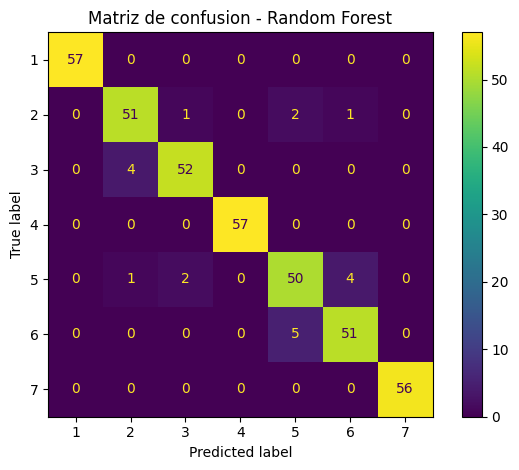

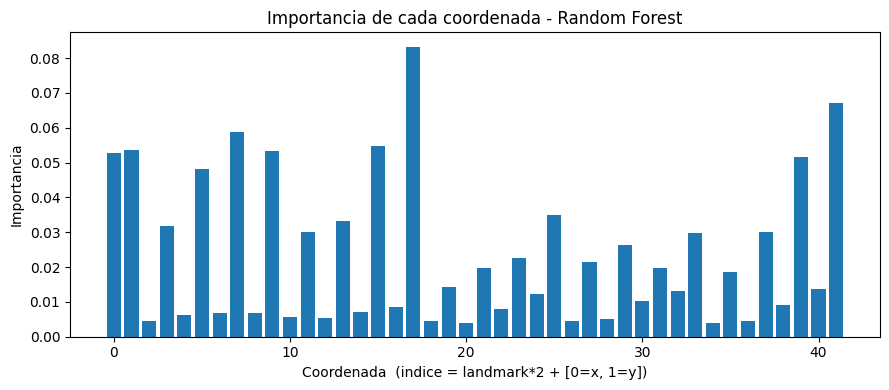

In [21]:
# === Random Forest: graficas para la memoria / issue #38 ===
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1) Matriz de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matriz de confusion - Random Forest")
plt.tight_layout()
plt.show()

# 2) Importancia de cada coordenada
plt.figure(figsize=(9, 4))
plt.bar(range(len(importancias)), importancias)
plt.xlabel("Coordenada  (indice = landmark*2 + [0=x, 1=y])")
plt.ylabel("Importancia")
plt.title("Importancia de cada coordenada - Random Forest")
plt.tight_layout()
plt.show()


## 14. Random Forest — guardar el modelo (.pkl)

In [22]:
import joblib, os

root_filename = 'PIDS_6gestos_v1'

# 1) Guardar en la carpeta de modelos del repo (temporal en Colab)
os.makedirs(models_path, exist_ok=True)
pkl_repo = os.path.join(models_path, f"{root_filename}_{network_type}.pkl")
joblib.dump(model, pkl_repo)
print(f'[MODEL SAVED][{pkl_repo}]')
print(f'[MODEL SIZE = {os.path.getsize(pkl_repo)/1e6:.2f} MB]')

# 2) Copia de seguridad en tu Drive (persistente tras reiniciar Colab)
drive_dir = "/content/drive/MyDrive/PIDS_modelos/"
os.makedirs(drive_dir, exist_ok=True)
pkl_drive = os.path.join(drive_dir, f"{root_filename}_{network_type}.pkl")
joblib.dump(model, pkl_drive)
print(f'[BACKUP EN DRIVE][{pkl_drive}]')

# NOTA: Random Forest no usa StandardScaler aquí, así que no hay scaler que guardar.


[MODEL SAVED][HAR_mediapipe/models/PIDS_6gestos_v1_RANDOM-FOREST.pkl]
[MODEL SIZE = 3.67 MB]
[BACKUP EN DRIVE][/content/drive/MyDrive/PIDS_modelos/PIDS_6gestos_v1_RANDOM-FOREST.pkl]
